# Assignment 6: Model Evaluation, Explainability, and Fairness Reflection

**Course:** AI Programming  

**Dataset used:** Hotel Booking Cancellation dataset  

**Goal of this notebook:** Build a simple classification model that predicts whether a hotel booking will be cancelled, then evaluate it, explain it, study its mistakes, and reflect on fairness.

In this notebook the model is a Decision Tree. The target column is booking_cancelled, where the value 1 means the booking was cancelled and the value 0 means the booking was kept. Every task below is written in plain language so the steps are easy to follow.

## Task 1: Load and Understand the Dataset

Before building any model, we first load the data and look at its basic shape. We check how many rows and columns there are, the column names, the data types, the missing values, the duplicate rows, and how the target column is spread out. This helps us understand the data before we train anything.

In [53]:
# Bringing in the pandas library, which gives us easy tools to open and work with tables of data
import pandas as pd

# Bringing in matplotlib, the library that draws all of our charts
import matplotlib.pyplot as plt

# Bringing in a small helper that lets us build our own colour map for the confusion matrix picture
from matplotlib.colors import LinearSegmentedColormap

# Setting one custom colour theme so every chart in this notebook shares the same look
# Listing the main theme colours: deep teal, warm coral, soft gold, dark navy, and light orange
theme_colors = ["#2A9D8F", "#E76F51", "#E9C46A", "#264653", "#F4A261"]

# Telling matplotlib to use these theme colours, in this order, for every chart we draw
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=theme_colors)

# Building a smooth colour map that goes from white up to teal, used later for the confusion matrix
theme_cmap = LinearSegmentedColormap.from_list("theme", ["#FFFFFF", "#2A9D8F"])

# Bringing in a settings tool from scikit-learn
from sklearn import set_config

# Telling scikit-learn to show a trained model as plain simple text instead of an interactive diagram
# Keeping it as text makes the training output clean and removes the extra HTML message
set_config(display="text")

# Reading the booking data file from inside the data folder and saving it in a table named df
df = pd.read_csv("data/hotel_booking_cancellation_dataset.csv")

# Showing the first five rows so we can see what kind of information each booking holds
df.head()

,booking_id,guest_age,age_group,guest_type,region,booking_channel,room_type,number_of_guests,number_of_nights,lead_time_days,average_daily_rate,special_requests,previous_cancellations,deposit_type,is_weekend_stay,booking_cancelled
0,H0001,25,18-25,Family,West,Online Travel Agency,Standard,2,5,50,298.33,4,2,No Deposit,No,1
1,H0002,29,26-35,Couple,East,Corporate,Standard,1,10,226,358.85,2,0,No Deposit,No,1
2,H0003,47,36-50,Family,East,Phone,Standard,1,9,15,304.06,3,0,No Deposit,Yes,0
3,H0004,68,51+,Family,North,Online Travel Agency,Standard,2,5,120,249.40,3,0,No Deposit,Yes,0
4,H0005,60,51+,Business,North,Online Travel Agency,Deluxe,3,7,102,356.47,1,0,No Deposit,Yes,1


In [54]:
# Looking at the size of the table, where the first number is the count of rows and the second is the count of columns
# Each row stands for one booking and each column stands for one detail about that booking
df.shape

(350, 16)

In [55]:
# Listing the names of all the columns so we know exactly what details the dataset gives us
df.columns

Index(['booking_id', 'guest_age', 'age_group', 'guest_type', 'region',
       'booking_channel', 'room_type', 'number_of_guests', 'number_of_nights',
       'lead_time_days', 'average_daily_rate', 'special_requests',
       'previous_cancellations', 'deposit_type', 'is_weekend_stay',
       'booking_cancelled'],
      dtype='object')

In [56]:
# Checking the data type of every column and how many values are filled in
# This tells us which columns hold numbers and which columns hold words
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   booking_id              350 non-null    object 
 1   guest_age               350 non-null    int64  
 2   age_group               350 non-null    object 
 3   guest_type              350 non-null    object 
 4   region                  350 non-null    object 
 5   booking_channel         350 non-null    object 
 6   room_type               350 non-null    object 
 7   number_of_guests        350 non-null    int64  
 8   number_of_nights        350 non-null    int64  
 9   lead_time_days          350 non-null    int64  
 10  average_daily_rate      344 non-null    float64
 11  special_requests        350 non-null    int64  
 12  previous_cancellations  350 non-null    int64  
 13  deposit_type            350 non-null    object 
 14  is_weekend_stay         350 non-null    ob

In [57]:
# Counting the empty cells in each column so we can find any place where information is missing
df.isnull().sum()

booking_id                0
guest_age                 0
age_group                 0
guest_type                0
region                    0
booking_channel           0
room_type                 0
number_of_guests          0
number_of_nights          0
lead_time_days            0
average_daily_rate        6
special_requests          0
previous_cancellations    0
deposit_type              0
is_weekend_stay           0
booking_cancelled         0
dtype: int64

In [58]:
# Counting how many rows are exact copies of another row, because repeated rows can give the model a wrong picture
df.duplicated().sum()

np.int64(0)

In [59]:
# Counting how many bookings were kept and how many were cancelled
# Reading this as 0 meaning the booking was kept and 1 meaning the booking was cancelled
df["booking_cancelled"].value_counts()

booking_cancelled
0    193
1    157
Name: count, dtype: int64

In [60]:
# Showing the same two counts as percentages so we can see the balance between kept and cancelled more clearly
df["booking_cancelled"].value_counts(normalize=True) * 100

booking_cancelled
0    55.142857
1    44.857143
Name: proportion, dtype: float64

### What this dataset shows

The dataset has 350 rows and 16 columns. Each row is one hotel booking and each column is one detail about that booking, such as the guest age, the guest type, the region, the lead time, the number of nights, the room price, and whether the booking was cancelled.

I checked for duplicate rows first, because repeated rows would make some bookings count twice and bias the model, and there were none. I then checked for missing values, because the model cannot work with empty cells. Only one column, average_daily_rate, had missing values, 6 in total. I will fill these in the preprocessing step using the median price of about 257.24, and I use the median rather than the average because the median is a middle value that is not pulled around by a few very high or very low prices.

The target column is booking_cancelled. About 193 bookings were kept, close to 55 percent, and about 157 were cancelled, close to 45 percent. This near even split matters, because when the two answers appear about as often as each other, the model has a fair chance to learn both and is not tempted to simply always guess the more common answer. So the target is reasonably balanced and not strongly imbalanced.

## Task 2: Define Features and Target Variable

Now we separate the data into two parts. The first part is the target, which is the column we want to predict. The second part is the input features, which are the columns the model uses to make the prediction. We also set aside the group columns so we can use them later for fairness, and we remove the identifier column because it has no predictive value.

In [61]:
# Choosing the column we want to predict and saving it as y
# Treating this column as the target, which is the answer the model will try to guess
y = df["booking_cancelled"]

# Building the input table X by keeping every column except two
# Dropping booking_id because it is only a name tag for each booking and does not help the guess
# Dropping booking_cancelled because that column is the answer itself and cannot be used as an input
X = df.drop(columns=["booking_id", "booking_cancelled"])

# Showing the first rows of the input table so we can check what is left
X.head()

,guest_age,age_group,guest_type,region,booking_channel,room_type,number_of_guests,number_of_nights,lead_time_days,average_daily_rate,special_requests,previous_cancellations,deposit_type,is_weekend_stay
0,25,18-25,Family,West,Online Travel Agency,Standard,2,5,50,298.33,4,2,No Deposit,No
1,29,26-35,Couple,East,Corporate,Standard,1,10,226,358.85,2,0,No Deposit,No
2,47,36-50,Family,East,Phone,Standard,1,9,15,304.06,3,0,No Deposit,Yes
3,68,51+,Family,North,Online Travel Agency,Standard,2,5,120,249.40,3,0,No Deposit,Yes
4,60,51+,Business,North,Online Travel Agency,Deluxe,3,7,102,356.47,1,0,No Deposit,Yes


In [62]:
# Saving the group columns in a separate table so we can use them later in the fairness step
# Keeping these columns aside because they describe the kind of guest, and we do not want the model to decide using them
fairness_columns = df[["age_group", "region", "guest_type"]]

# Removing these group columns from the input table so they are not fed to the model
X = X.drop(columns=["age_group", "region", "guest_type"])

# Showing the input table again to make sure the group columns are now gone
X.head()

,guest_age,booking_channel,room_type,number_of_guests,number_of_nights,lead_time_days,average_daily_rate,special_requests,previous_cancellations,deposit_type,is_weekend_stay
0,25,Online Travel Agency,Standard,2,5,50,298.33,4,2,No Deposit,No
1,29,Corporate,Standard,1,10,226,358.85,2,0,No Deposit,No
2,47,Phone,Standard,1,9,15,304.06,3,0,No Deposit,Yes
3,68,Online Travel Agency,Standard,2,5,120,249.40,3,0,No Deposit,Yes
4,60,Online Travel Agency,Deluxe,3,7,102,356.47,1,0,No Deposit,Yes


### Which column is which

The target variable is booking_cancelled, so every other column was a possible input.

The input features I kept are guest_age, booking_channel, room_type, number_of_guests, number_of_nights, lead_time_days, average_daily_rate, special_requests, previous_cancellations, deposit_type, and is_weekend_stay, because these describe the booking itself.

I removed booking_id, because it is a unique label for each booking and holds no pattern the model could learn from.

I also set aside three group columns, age_group, region, and guest_type, and did not give them to the model. I did this on purpose, because I did not want the model to decide whether a booking will cancel based on the group a guest belongs to, which could be unfair. I kept these three columns only for the fairness check in Task 14.

## Task 3: Data Preprocessing

A machine learning model can only work with numbers, and it cannot handle empty values. So before training we do two things. First we fill the missing values. Second we change the text columns into number columns. This is why preprocessing is needed: without it the model would either crash on the missing values or fail to read the text categories.

In [63]:
# Finding the middle value of the room price column, which is called the median
# Picking the median because it is a safe middle point that very high or very low prices do not pull around
median_rate = df["average_daily_rate"].median()

# Filling every empty room price cell with that middle value so no cell is left blank
X["average_daily_rate"] = X["average_daily_rate"].fillna(median_rate)

# Counting the empty cells again to make sure nothing is missing now
X.isnull().sum()

guest_age                 0
booking_channel           0
room_type                 0
number_of_guests          0
number_of_nights          0
lead_time_days            0
average_daily_rate        0
special_requests          0
previous_cancellations    0
deposit_type              0
is_weekend_stay           0
dtype: int64

In [64]:
# Turning the word columns into number columns so the model is able to read them
# Using a method called one-hot encoding, which creates simple columns filled with zeros and ones
# Setting drop_first to True so it removes one repeated column for each category and keeps the table tidy
X = pd.get_dummies(X, drop_first=True)

# Showing the final input table, which is now made only of numbers
X.head()

,guest_age,number_of_guests,number_of_nights,lead_time_days,average_daily_rate,special_requests,previous_cancellations,booking_channel_Direct,booking_channel_Online Travel Agency,booking_channel_Phone,room_type_Standard,room_type_Suite,deposit_type_Non-refundable,deposit_type_Partial Deposit,is_weekend_stay_Yes
0,25,2,5,50,298.33,4,2,False,True,False,True,False,False,False,False
1,29,1,10,226,358.85,2,0,False,False,False,True,False,False,False,False
2,47,1,9,15,304.06,3,0,False,False,True,True,False,False,False,True
3,68,2,5,120,249.40,3,0,False,True,False,True,False,False,False,True
4,60,3,7,102,356.47,1,0,False,True,False,False,False,False,False,True


In [65]:
# Checking how many input columns we have after turning all the words into numbers
X.shape

(350, 15)

### Why preprocessing matters

I filled the 6 missing values in average_daily_rate with the median of that column, which is about 257.24. Filling the gaps means the model has a complete table to learn from, since it cannot do maths on an empty cell. I chose the median because it is a middle value that a few very high or very low prices do not pull around.

I then used one hot encoding to turn the text columns such as booking_channel, room_type, deposit_type, and is_weekend_stay into number columns of zeros and ones, because a model can only work with numbers and cannot read words like Standard or Phone. After encoding, the feature set had 15 columns.

So preprocessing is necessary for one simple reason: the model learns from clean, complete numbers only. Cleaning the missing values and changing the text into numbers first makes sure the model receives data it can actually use.

## Task 4: Train Test Split

We now split the data into two groups. The training set is used to teach the model. The testing set is kept separate and is used to check how well the model works on bookings it has never seen. We use stratify so that both groups keep the same balance of cancelled and kept bookings.

In [66]:
# Bringing in the tool that splits the data into a learning part and a testing part
from sklearn.model_selection import train_test_split

# Splitting the inputs, the answers, and the group columns all at the same time so their rows stay matched
# Keeping 20 percent of the bookings aside for testing and using the other 80 percent for learning
# Setting random_state to 42 so the split comes out the same every time we run the notebook
# Using stratify so both the learning part and the testing part keep the same share of cancelled bookings
X_train, X_test, y_train, y_test, fair_train, fair_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Printing the size of each part so we can see how many bookings went into learning and how many into testing
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (280, 15)
Testing features shape: (70, 15)
Training target shape: (280,)
Testing target shape: (70,)


### Why we split the data

The training set has 280 bookings and the testing set has 70 bookings, which is an 80 to 20 split.

The difference between the two is simple. The training data is the part the model studies and learns from. The testing data is hidden from the model during training and is only used at the end to measure how well it predicts new bookings. I keep them separate because a fair test must use data the model has not seen. If I tested on the same data I trained on, the score would look good but would not tell me how the model behaves with real new bookings.

I also used a stratified split, which keeps the same balance of cancelled and kept bookings in both parts, so the test set is a fair sample of the whole dataset.

## Task 5: Train a Classification Model

We train a Decision Tree model. A Decision Tree learns simple yes or no rules from the features, such as whether the lead time is long or short, and uses these rules to decide if a booking will be cancelled. We keep the tree shallow with a depth of 4 so it stays simple and easy to read.

In [67]:
# Bringing in the Decision Tree model, which learns by asking simple yes or no questions about the features
from sklearn.tree import DecisionTreeClassifier

# Creating the model and keeping it small with a depth of only 4 so the rules stay simple and easy to follow
# Setting random_state to 42 so we build the very same tree every time we run it
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Teaching the model using the training data
# Letting the model study the input features together with the matching answers so it can learn the pattern
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [68]:
# Asking the trained model to guess the result for every booking in the test set
y_pred = model.predict(X_test)

# Building a small table that places the real answer next to the guess made by the model
comparison = pd.DataFrame({
    "Actual Cancelled": y_test.values,
    "Predicted Cancelled": y_pred
})

# Showing the first ten rows so we can compare the real answers with the guesses
comparison.head(10)

,Actual Cancelled,Predicted Cancelled
0,1,1
1,0,0
2,1,1
3,0,0
4,1,0
5,1,1
6,0,1
7,0,0
8,1,1
9,0,0


### What the model is learning

The model is trying to learn which booking features point to a cancellation. It asks simple questions about a booking, such as whether the lead time is long or whether the guest has cancelled before, and follows the answers down its branches to a final answer of cancel or keep.

Looking at the first ten predictions, the model gets eight of them right. In two rows it is wrong. In one row the booking was actually cancelled but the model said it would be kept, which is a missed cancellation, and in the other row the booking was actually kept but the model said it would be cancelled, which is a false alarm. This early view is encouraging, but ten rows are not enough to judge the model, so I measure it properly in the next steps.

## Task 6: Evaluate the Model

We now measure the model using four common scores: accuracy, precision, recall, and the F1 score. Each one tells us something different about how the model performs.

In [69]:
# Bringing in the four scoring tools we will use to judge how good the model is
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Asking the model to guess the answers for the test bookings
y_pred = model.predict(X_test)

# Measuring accuracy, which is the share of all the guesses that turned out correct
accuracy = accuracy_score(y_test, y_pred)

# Measuring precision, which checks how often a cancel guess was really a cancel
precision = precision_score(y_test, y_pred, zero_division=0)

# Measuring recall, which checks how many of the real cancellations the model managed to catch
recall = recall_score(y_test, y_pred, zero_division=0)

# Measuring the F1 score, which blends precision and recall into one balanced number
f1 = f1_score(y_test, y_pred, zero_division=0)

# Gathering the four scores into one clear table
metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

# Showing the table of scores
metrics_results

,Metric,Score
0,Accuracy,0.714286
1,Precision,0.720000
2,Recall,0.580645
3,F1-Score,0.642857


### What each score means and which one matters most

I measured the model with four scores, and each one answers a different question.

The accuracy is about 0.71, which means the model predicted about 71 of every 100 test bookings correctly. Accuracy on its own can hide problems, so I also looked at precision and recall, which split the mistakes in two useful ways.

The precision is about 0.72, which answers the question, when the model flags a booking as a cancellation, how often is it right, and the answer is about 72 times out of 100.

The recall is about 0.58, which answers a different question, out of all the bookings that really cancelled, how many did the model catch, and here it caught only about 58 of every 100.

The gap between precision and recall is the key point. The model is fairly trustworthy when it does raise a flag, but it lets a large share of real cancellations slip by without any flag. The F1 score, which balances precision and recall, is about 0.64, sitting between the two as expected.

For this hotel problem, recall is the most important score, because the main goal is to catch the bookings that will cancel so the room can be sold again in time. A missed cancellation is the expensive outcome. A recall of 0.58 means the model is missing close to half of the real cancellations, which is the clearest sign that it still needs work.

## Task 7: Confusion Matrix

A confusion matrix shows the four possible outcomes of the predictions in one table. It tells us not only how many mistakes the model made, but also what kind of mistakes they were.

In [70]:
# Bringing in the tools that build the confusion matrix and draw it as a picture
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Building the confusion matrix by comparing the real answers with the guesses
cm = confusion_matrix(y_test, y_pred)

# Pulling the four numbers out of the matrix one by one
# Reading tn as correct kept, fp as wrong cancel, fn as missed cancel, and tp as correct cancel
tn, fp, fn, tp = cm.ravel()

# Putting the matrix into a labelled table so each number is easy to understand
cm_table = pd.DataFrame(
    cm,
    index=["Actual Kept (0)", "Actual Cancelled (1)"],
    columns=["Predicted Kept (0)", "Predicted Cancelled (1)"]
)

# Showing the confusion matrix table
cm_table

,Predicted Kept (0),Predicted Cancelled (1)
Actual Kept (0),32,7
Actual Cancelled (1),13,18


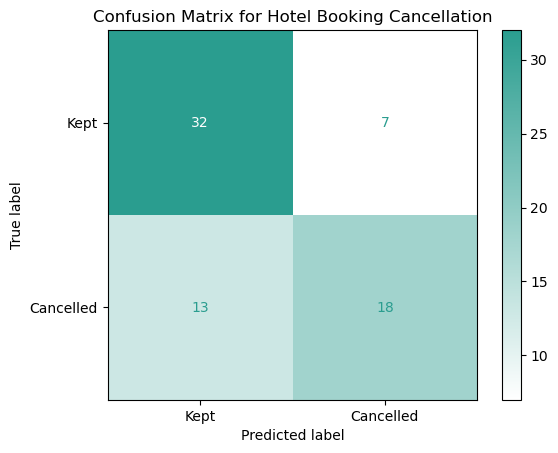

In [71]:
# Preparing a coloured picture of the confusion matrix with clear word labels
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Kept", "Cancelled"]
)

# Drawing the picture using our custom teal colour map so it matches the notebook theme
display.plot(cmap=theme_cmap)

# Adding a title on top of the picture
plt.title("Confusion Matrix for Hotel Booking Cancellation")

# Showing the picture on the screen
plt.show()

In [72]:
# Building a small table that explains in plain words what each of the four numbers means
confusion_summary = pd.DataFrame({
    "Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Meaning": [
        "The model correctly said the booking would be kept",
        "The model said cancel, but the booking was actually kept",
        "The model said kept, but the booking was actually cancelled",
        "The model correctly said the booking would be cancelled"
    ],
    "Value": [tn, fp, fn, tp]
})

# Showing the explanation table
confusion_summary

,Type,Meaning,Value
0,True Negative,The model correctly said the booking would be ...,32
1,False Positive,"The model said cancel, but the booking was act...",7
2,False Negative,"The model said kept, but the booking was actua...",13
3,True Positive,The model correctly said the booking would be ...,18


### Reading the confusion matrix

The confusion matrix splits the 70 test results into four groups, which shows not just how many mistakes the model made but what kind. The four results are True Negative 32, False Positive 7, False Negative 13, and True Positive 18.

The model correctly kept 32 bookings and correctly flagged 18 cancellations, so it was right on 50 of the 70 bookings. It made 20 mistakes, and they are not the same kind. In 7 cases it flagged a booking as a cancellation when the guest actually kept it, which is a false positive, or false alarm. In 13 cases it said a booking would be kept when the guest actually cancelled, which is a false negative, or missed cancellation.

A false alarm only wastes a little effort, for example contacting a guest who was never going to leave. A missed cancellation is worse, because the room suddenly becomes empty with little warning, the hotel has no time to resell it, and that night may be lost revenue.

For a hotel the false negative is usually the more serious error, and in this model the false negatives (13) outnumber the false positives (7), so the model is making more of the costly kind of mistake. This is the detail that matters most.

## Task 8: Error Analysis

Now we look more closely at the mistakes. Instead of just counting them, we label every prediction as one of the four types and then look at the wrong ones in detail. This helps connect the technical errors to real business meaning.

In [73]:
# Building a table that lines up the booking id, the real answer, and the guess side by side
error_analysis = pd.DataFrame({
    "Booking ID": df.loc[y_test.index, "booking_id"].values,
    "Actual Cancelled": y_test.values,
    "Predicted Cancelled": y_pred
})

# Adding a column that says True when the guess matches the real answer and False when it does not
error_analysis["Correct Prediction"] = (
    error_analysis["Actual Cancelled"] == error_analysis["Predicted Cancelled"]
)

# Showing the first ten rows of this table
error_analysis.head(10)

,Booking ID,Actual Cancelled,Predicted Cancelled,Correct Prediction
0,H0286,1,1,True
1,H0189,0,0,True
2,H0113,1,1,True
3,H0198,0,0,True
4,H0147,1,0,False
5,H0081,1,1,True
6,H0127,0,1,False
7,H0133,0,0,True
8,H0002,1,1,True
9,H0243,0,0,True


In [74]:
# Writing a small helper that gives each booking one of the four error labels
def classify_error(row):
    # Returning True Negative when the booking was kept and the model also said kept
    if row["Actual Cancelled"] == 0 and row["Predicted Cancelled"] == 0:
        return "True Negative"
    # Returning False Positive when the booking was kept but the model said cancel
    elif row["Actual Cancelled"] == 0 and row["Predicted Cancelled"] == 1:
        return "False Positive"
    # Returning False Negative when the booking was cancelled but the model said kept
    elif row["Actual Cancelled"] == 1 and row["Predicted Cancelled"] == 0:
        return "False Negative"
    # Returning True Positive when the booking was cancelled and the model also said cancel
    else:
        return "True Positive"

# Running the helper on every row to create a new column called Error Type
error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)

# Showing the first ten rows together with their error type
error_analysis.head(10)

,Booking ID,Actual Cancelled,Predicted Cancelled,Correct Prediction,Error Type
0,H0286,1,1,True,True Positive
1,H0189,0,0,True,True Negative
2,H0113,1,1,True,True Positive
3,H0198,0,0,True,True Negative
4,H0147,1,0,False,False Negative
5,H0081,1,1,True,True Positive
6,H0127,0,1,False,False Positive
7,H0133,0,0,True,True Negative
8,H0002,1,1,True,True Positive
9,H0243,0,0,True,True Negative


In [75]:
# Counting how many times each error type appears in the test set
error_counts = error_analysis["Error Type"].value_counts().reset_index()

# Renaming the two columns so the table reads clearly
error_counts.columns = ["Error Type", "Count"]

# Showing the count table
error_counts

,Error Type,Count
0,True Negative,32
1,True Positive,18
2,False Negative,13
3,False Positive,7


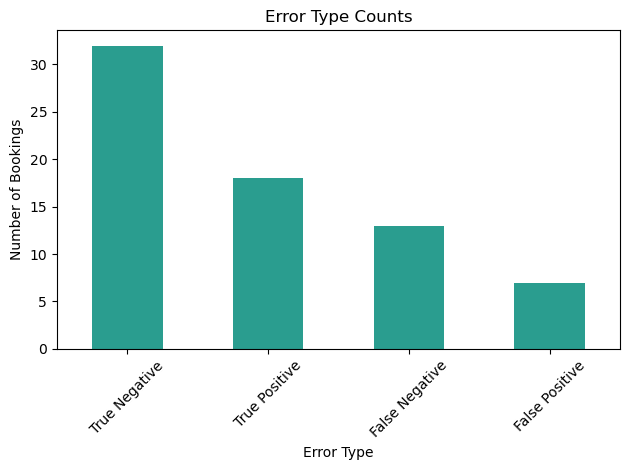

In [76]:
# Drawing a bar chart that shows the count of each error type, painted in our theme teal
error_counts.plot(x="Error Type", y="Count", kind="bar", legend=False, color="#2A9D8F")

# Adding a title on top of the chart
plt.title("Error Type Counts")

# Adding a label under the bars
plt.xlabel("Error Type")

# Adding a label on the side of the chart
plt.ylabel("Number of Bookings")

# Turning the bottom labels a little so they do not overlap each other
plt.xticks(rotation=45)

# Tidying the layout so nothing gets cut off
plt.tight_layout()

# Showing the chart
plt.show()

In [77]:
# Keeping only the rows where the guess did not match the real answer
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]

# Showing the first ten wrong guesses
wrong_predictions.head(10)

,Booking ID,Actual Cancelled,Predicted Cancelled,Correct Prediction,Error Type
4,H0147,1,0,False,False Negative
6,H0127,0,1,False,False Positive
10,H0273,1,0,False,False Negative
11,H0222,1,0,False,False Negative
12,H0156,1,0,False,False Negative
20,H0341,0,1,False,False Positive
24,H0322,0,1,False,False Positive
30,H0116,1,0,False,False Negative
31,H0252,1,0,False,False Negative
34,H0336,1,0,False,False Negative


### What the errors tell us

When I count the four types, I get 32 True Negatives, 18 True Positives, 13 False Negatives, and 7 False Positives. The two correct types are the largest, which is a good sign.

Among the mistakes only, the most common error is the False Negative, the missed cancellation, with 13 cases against only 7 false alarms, so missed cancellations make up almost two thirds of all the errors.

The business impact is direct. When the model misses a cancellation, the hotel still expects that room to be filled, so it does not try to resell it, and the room can sit empty at the last moment with no time to recover the income. A false alarm only wastes a little effort, but a missed cancellation loses a night of revenue, so reducing these 13 missed cancellations should be the first goal if the model is improved.

## Task 9: Cross-Validation

A single train test split can be lucky or unlucky. Cross-validation checks the model many times on different parts of the data. This tells us whether the performance is stable or whether it changes a lot depending on the split.

In [78]:
# Bringing in the tools that run cross-validation and keep the class balance in each part
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Setting up a plan that cuts the data into 5 equal parts and keeps the cancel balance inside each part
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Training and testing the model 5 times on different parts and saving the accuracy from each round
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# Placing the five round scores into a table
cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})

# Showing the table of fold scores
cv_results

,Fold,Accuracy
0,Fold 1,0.757143
1,Fold 2,0.771429
2,Fold 3,0.714286
3,Fold 4,0.671429
4,Fold 5,0.642857


In [79]:
# Working out the average accuracy across all five rounds
mean_cv_accuracy = cv_scores.mean()

# Working out how much the accuracy moves up and down between the rounds
std_cv_accuracy = cv_scores.std()

# Placing the average and the spread into one short summary table
cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value": [mean_cv_accuracy, std_cv_accuracy]
})

# Showing the summary table
cv_summary

,Metric,Value
0,Mean Cross-Validation Accuracy,0.711429
1,Standard Deviation,0.048990


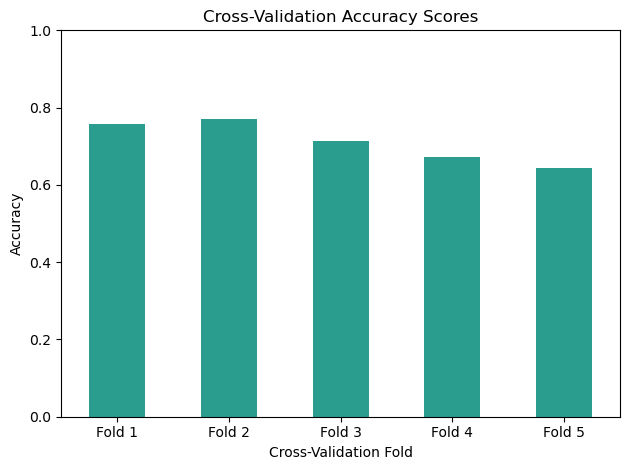

In [80]:
# Drawing a bar chart that shows the accuracy of each fold, painted in our theme teal
cv_results.plot(x="Fold", y="Accuracy", kind="bar", legend=False, color="#2A9D8F")

# Adding a title on top of the chart
plt.title("Cross-Validation Accuracy Scores")

# Adding a label under the bars
plt.xlabel("Cross-Validation Fold")

# Adding a label on the side of the chart
plt.ylabel("Accuracy")

# Setting the side scale from 0 to 1 so the bars are easy to compare
plt.ylim(0, 1)

# Keeping the bottom labels straight
plt.xticks(rotation=0)

# Tidying the layout
plt.tight_layout()

# Showing the chart
plt.show()

### Is the model stable

The five fold scores are about 0.76, 0.77, 0.71, 0.67, and 0.64. The mean accuracy is about 0.71 and the spread, measured as the standard deviation, is only about 0.05.

The reason this matters is stability. The lowest fold at 0.64 and the highest fold at 0.77 are not far apart, and the average lands right on the single test score I found earlier, which tells me the 0.71 result is believable and not a one off. There is some movement between folds, which is normal for a small dataset of only 350 rows, but nothing that suggests the model swings wildly from one split to another.

## Task 10: Overfitting and Underfitting Analysis

Overfitting happens when a model learns the training data too well but fails on new data. Underfitting happens when a model is too simple to learn the pattern. We compare training and testing accuracy, and we test many tree depths, to see which problem our model has.

In [81]:
# Bringing in the accuracy score tool
from sklearn.metrics import accuracy_score

# Measuring how well the model does on the same data it learned from
train_accuracy = accuracy_score(y_train, model.predict(X_train))

# Measuring how well the model does on the new test data it has not seen before
test_accuracy = accuracy_score(y_test, model.predict(X_test))

# Placing the two scores side by side so we can compare learning and testing
overfitting_check = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})

# Showing the comparison table
overfitting_check

,Dataset,Accuracy
0,Training Data,0.789286
1,Testing Data,0.714286


In [82]:
# Making an empty list that will hold the scores for each tree depth
depth_results = []

# Going through tree depths from 1 up to 10 to see how the depth changes the scores
for depth in range(1, 11):
    # Creating a fresh tree that is allowed to grow to the current depth
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Teaching this tree on the training data
    temp_model.fit(X_train, y_train)
    # Measuring how well this tree does on the training data
    train_acc = accuracy_score(y_train, temp_model.predict(X_train))
    # Measuring how well this tree does on the test data
    test_acc = accuracy_score(y_test, temp_model.predict(X_test))
    # Saving the depth and its two scores into the list
    depth_results.append([depth, train_acc, test_acc])

# Turning the list of results into a clear table
depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

# Showing the table of scores for every depth
depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.721429,0.671429
1,2,0.778571,0.728571
2,3,0.782143,0.714286
3,4,0.789286,0.714286
4,5,0.846429,0.700000
5,6,0.875000,0.671429
6,7,0.903571,0.700000
7,8,0.950000,0.657143
8,9,0.967857,0.657143
9,10,0.985714,0.671429


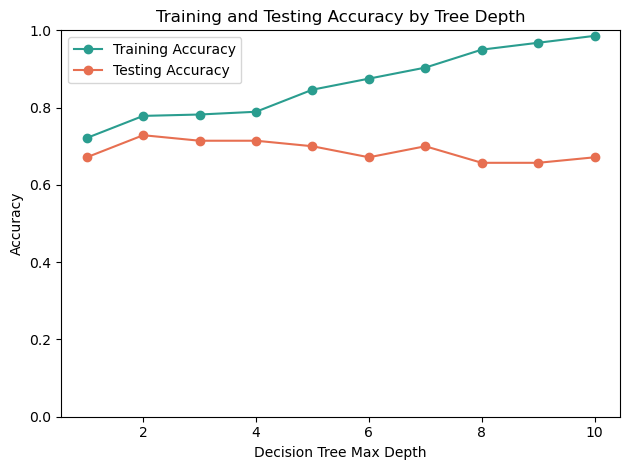

In [83]:
# Drawing a line that shows the training accuracy as the tree gets deeper
plt.plot(depth_results_df["Max Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")

# Drawing a second line that shows the testing accuracy as the tree gets deeper
plt.plot(depth_results_df["Max Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")

# Adding a title on top of the chart
plt.title("Training and Testing Accuracy by Tree Depth")

# Adding a label under the lines
plt.xlabel("Decision Tree Max Depth")

# Adding a label on the side of the chart
plt.ylabel("Accuracy")

# Setting the side scale from 0 to 1
plt.ylim(0, 1)

# Showing a small key that explains which line is which
plt.legend()

# Tidying the layout
plt.tight_layout()

# Showing the chart
plt.show()

### Overfitting or underfitting

For the depth 4 model, the training accuracy is about 0.79 and the testing accuracy is about 0.71, a gap of roughly 0.07. A small gap like this points to mild overfitting, which means the model learned the training bookings a little better than it can repeat on new ones.

The depth table makes the pattern clear. As the tree gets deeper, the training accuracy climbs steadily, from about 0.72 at depth one all the way to about 0.99 at depth ten, because a deeper tree can keep memorising more of the training data. The testing accuracy does the opposite. It is at its best at depth two, around 0.73, and then slowly drifts down into the high 0.60s at the deepest trees. This widening gap between the two lines is the textbook sign of overfitting.

The model is not underfitting, because even a very simple tree still reached the low 0.70s rather than failing badly. The useful lesson is that a shallow tree of depth 2 gives the best testing accuracy, around 0.73, slightly better than the depth 4 tree, so here simpler is better.

## Task 11: Feature Importance

Feature importance tells us which inputs the Decision Tree leaned on the most when making its predictions. It is a simple way to explain the model in business terms.

In [84]:
# Building a table that lists each feature next to its importance score taken from the trained tree
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

# Showing the full importance table, ordered from the most useful feature to the least useful
feature_importance_df

,Feature,Importance
3,lead_time_days,0.525785
6,previous_cancellations,0.205738
12,deposit_type_Non-refundable,0.093101
4,average_daily_rate,0.075496
0,guest_age,0.048688
5,special_requests,0.040819
1,number_of_guests,0.010372
2,number_of_nights,0.000000
7,booking_channel_Direct,0.000000
8,booking_channel_Online Travel Agency,0.000000


In [85]:
# Keeping only the ten most important features
top_features = feature_importance_df.head(10)

# Showing the top ten features
top_features

,Feature,Importance
3,lead_time_days,0.525785
6,previous_cancellations,0.205738
12,deposit_type_Non-refundable,0.093101
4,average_daily_rate,0.075496
0,guest_age,0.048688
5,special_requests,0.040819
1,number_of_guests,0.010372
2,number_of_nights,0.000000
7,booking_channel_Direct,0.000000
8,booking_channel_Online Travel Agency,0.000000


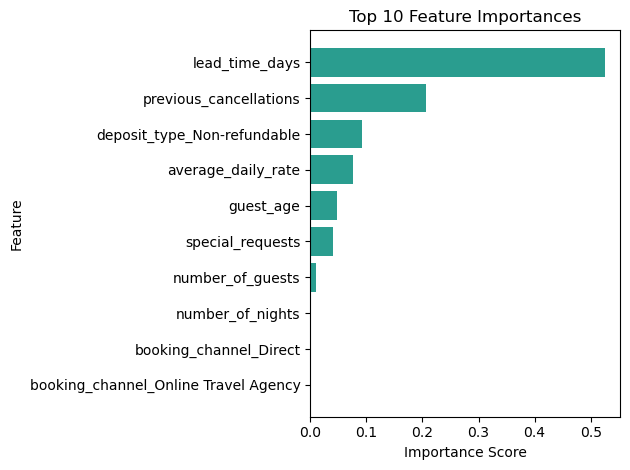

In [86]:
# Drawing a sideways bar chart of the top ten features in our theme teal colour
plt.barh(top_features["Feature"], top_features["Importance"], color="#2A9D8F")

# Adding a title on top of the chart
plt.title("Top 10 Feature Importances")

# Adding a label under the bars
plt.xlabel("Importance Score")

# Adding a label on the side of the chart
plt.ylabel("Feature")

# Flipping the order so the most important feature sits at the top of the chart
plt.gca().invert_yaxis()

# Tidying the layout
plt.tight_layout()

# Showing the chart
plt.show()

### What the important features mean

The model leaned on a small number of features, and the scores show just how unevenly. The most important by far is lead_time_days, with an importance score of about 0.53, which is more than half of all the importance on its own. Next comes previous_cancellations at about 0.21, then the non refundable deposit type at about 0.09 and average_daily_rate at about 0.08, with everything else much smaller.

So the model is really driven by two signals above all others, a long lead time and a history of cancelling. Several features, such as booking channel and room type, scored zero, which does not mean they are useless in general, only that this shallow tree did not need them once it had the stronger signals.

One caution is important here. Importance shows what the model used to separate cancelled from kept bookings, not what causes a cancellation. A long lead time being useful to the model does not prove that booking early makes a guest cancel.

## Task 12: SHAP Explanation

SHAP is a tool that explains model predictions in more detail than feature importance alone. It can show the overall effect of each feature, and it can also explain one single booking, including whether a feature pushed the prediction toward cancel or away from cancel.

In [87]:
# Bringing in the SHAP library, which explains why the model made each choice
import shap

# Creating a SHAP explainer that is made specially for tree models like our Decision Tree
explainer = shap.TreeExplainer(model)

# Working out the SHAP values for every booking in the test set
shap_values = explainer.shap_values(X_test)

# Choosing the values for the cancel class, because different SHAP versions hand back the data in different shapes
if isinstance(shap_values, list):
    # Picking the second set of values when SHAP returns a list
    shap_values_class1 = shap_values[1]
    base_value_class1 = explainer.expected_value[1]
else:
    # Picking the cancel class out of the three part array when SHAP returns an array
    shap_values_class1 = shap_values[:, :, 1]
    base_value_class1 = explainer.expected_value[1]

# Checking the shape of the values, which should be the number of test bookings by the number of features
shap_values_class1.shape

(70, 15)

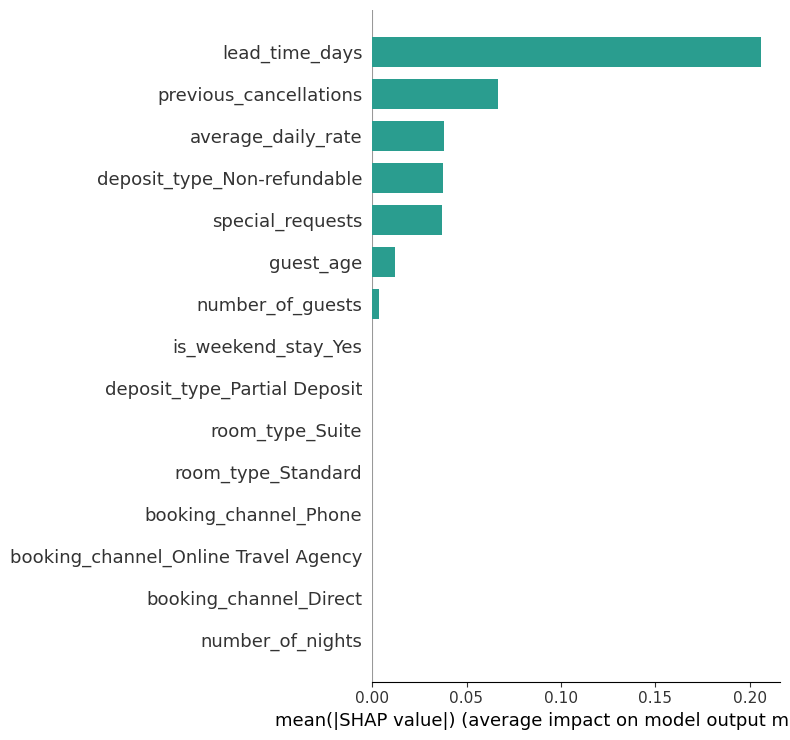

In [88]:
# Drawing the SHAP summary chart, which ranks the features by their average effect on the cancel guess
# Setting the bar colour to our theme teal so it matches the rest of the notebook
shap.summary_plot(shap_values_class1, X_test, plot_type="bar", color="#2A9D8F")

In [89]:
# Choosing one booking to explain, taking the first booking in the test set
customer_index = 0

# Getting the feature values for this one booking
one_booking_values = X_test.iloc[customer_index]

# Getting the SHAP values for this one booking
one_booking_shap = shap_values_class1[customer_index]

# Building a table that shows each feature, its value, and how much it moved the guess
one_booking_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": one_booking_values.values,
    "SHAP Value": one_booking_shap
})

# Adding a column that holds the size of the effect only, ignoring the plus or minus sign
one_booking_explanation["Absolute SHAP Value"] = one_booking_explanation["SHAP Value"].abs()

# Sorting the features from the strongest effect down to the weakest
one_booking_explanation = one_booking_explanation.sort_values("Absolute SHAP Value", ascending=False)

# Printing the real answer and the model guess for this booking
print("Actual:", int(y_test.iloc[customer_index]), " Predicted:", int(y_pred[customer_index]))

# Showing the eight strongest features for this booking
one_booking_explanation.head(8)

Actual: 1  Predicted: 1


,Feature,Feature Value,SHAP Value,Absolute SHAP Value
3,lead_time_days,181,0.279821,0.279821
5,special_requests,4,-0.081581,0.081581
4,average_daily_rate,308.75,-0.042791,0.042791
6,previous_cancellations,0,-0.021501,0.021501
0,guest_age,60,0.010452,0.010452
12,deposit_type_Non-refundable,False,0.008466,0.008466
1,number_of_guests,4,0.001786,0.001786
2,number_of_nights,6,0.000000,0.000000


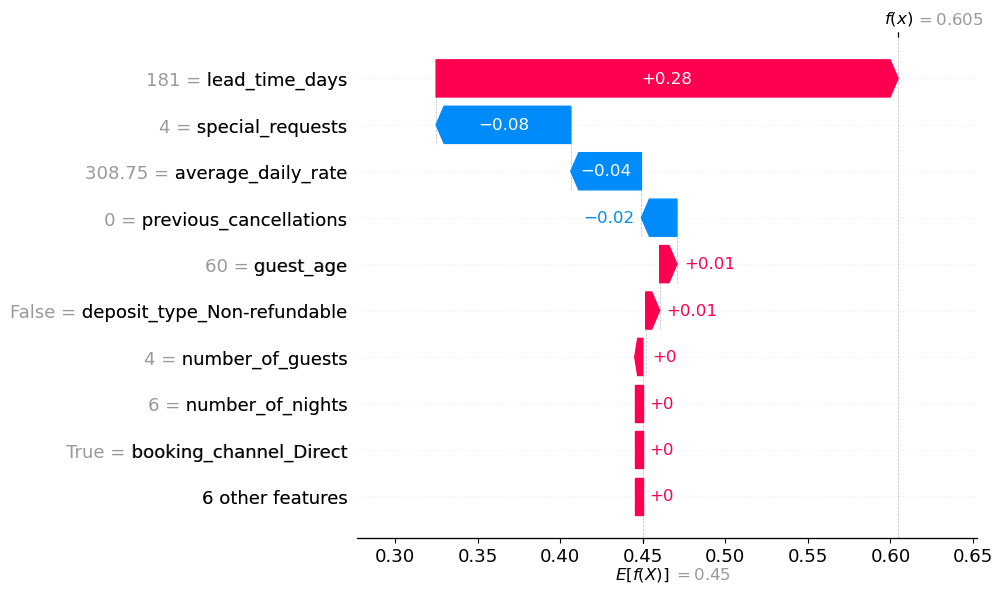

In [90]:
# Packing the values for this one booking into a SHAP object so we are able to draw it
single_explanation = shap.Explanation(
    values=one_booking_shap,
    base_values=base_value_class1,
    data=one_booking_values,
    feature_names=X_test.columns
)

# Drawing a waterfall picture that shows how each feature pushed the guess up toward cancel or down toward kept
shap.plots.waterfall(single_explanation)

### What SHAP tells us

SHAP explains the model in more depth, both overall and for a single booking. Overall it agrees with the importance ranking that lead time has the largest effect, with previous cancellations, the room price, and the deposit type next, which gives me confidence these are the real drivers.

One small difference is worth noting. SHAP places the room price just ahead of the deposit type, while the plain importance score had them the other way around. This kind of difference is normal, because the two methods measure influence in slightly different ways, and it is a good reason to look at more than one explanation rather than trust a single ranking.

SHAP can also explain one booking. The first booking in the test set was actually cancelled, and the model predicted cancel with a probability of about 0.60. The model starts from a base value of about 0.45, the average cancel chance, and for this booking the long lead time of 181 days pushed the prediction up by about 0.28, which was by far the strongest push, while a few smaller features nudged it the other way but not enough to change the answer.

The value of SHAP is that it shows direction, not just strength, so I can see which features pushed this booking toward cancel and which pushed it away.

## Task 13: LIME Explanation

LIME explains one single prediction in a simple way. It looks closely around one booking and builds an easy local view of which features supported the prediction and which features worked against it. This is helpful for business users who want to understand one decision.

In [91]:
# Turning off warning messages so the output below stays clean and easy to read
import warnings
warnings.filterwarnings("ignore")

# Bringing in the LIME tool that explains one prediction at a time
from lime.lime_tabular import LimeTabularExplainer

# Making number only copies of the data, because LIME works best with plain numbers
X_train_lime = X_train.astype(float)
X_test_lime = X_test.astype(float)

# Saving the list of feature names so LIME can label its output
feature_names = X_train_lime.columns.tolist()

# Naming the two possible answers in plain words
class_names = ["Not Cancelled", "Cancelled"]

# Building the LIME explainer and giving it the training data to use as its background
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

In [92]:
# Picking the same booking we explained with SHAP, the first one in the test set
customer_index = 0
one_booking = X_test_lime.iloc[customer_index]

# Getting the real answer for this booking
actual_value = int(y_test.iloc[customer_index])

# Getting the guess the model makes for this booking
predicted_value = int(model.predict(X_test_lime.iloc[[customer_index]])[0])

# Getting the chance the model gives to each possible answer
predicted_probabilities = model.predict_proba(X_test_lime.iloc[[customer_index]])[0]

# Placing the real answer, the guess, and the two chances into one small table
lime_prediction_result = pd.DataFrame({
    "Actual Cancelled": [actual_value],
    "Predicted Cancelled": [predicted_value],
    "Probability of Not Cancelled": [predicted_probabilities[0]],
    "Probability of Cancelled": [predicted_probabilities[1]]
})

# Showing this small result table
lime_prediction_result

,Actual Cancelled,Predicted Cancelled,Probability of Not Cancelled,Probability of Cancelled
0,1,1,0.395349,0.604651


In [93]:
# Asking LIME to explain this one booking and to return the top ten reasons
lime_explanation = lime_explainer.explain_instance(
    data_row=one_booking.values,
    predict_fn=model.predict_proba,
    num_features=10
)

# Turning the explanation into a readable table of conditions and their effect on the guess
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)

# Showing the explanation table
lime_explanation_table

,Feature Condition,Contribution
0,deposit_type_Non-refundable <= 0.00,0.207782
1,previous_cancellations <= 0.00,-0.144545
2,134.00 < lead_time_days <= 189.00,0.106373
3,48.00 < guest_age <= 62.00,0.045879
4,3.00 < number_of_guests <= 4.00,0.037359
5,3.00 < special_requests <= 4.00,-0.027124
6,257.24 < average_daily_rate <= 334.54,-0.024069
7,4.00 < number_of_nights <= 6.00,0.019082
8,room_type_Standard <= 0.00,-0.015107
9,booking_channel_Phone <= 0.00,-0.007277


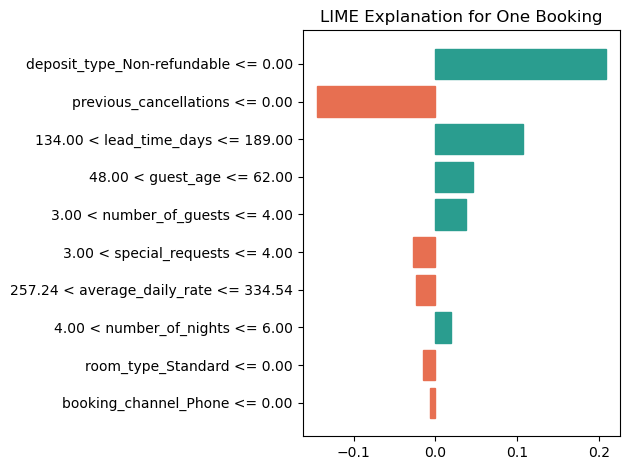

In [94]:
# Drawing the LIME explanation as a bar chart
fig = lime_explanation.as_pyplot_figure()

# Recolouring the bars so they match our theme
# Painting bars that push toward cancel in teal, and bars that push away from cancel in coral
for bar in fig.axes[0].patches:
    if bar.get_width() >= 0:
        bar.set_color("#2A9D8F")
    else:
        bar.set_color("#E76F51")

# Adding a title on top of the chart
plt.title("LIME Explanation for One Booking")

# Tidying the layout
plt.tight_layout()

# Showing the chart
plt.show()

### What LIME tells us

LIME explains one prediction in a simple, local way, by building an easy view around that single booking. For the same first booking, LIME also predicted cancel with a probability of about 0.60, which agrees with SHAP.

It then lists the reasons with a size for each. The two strongest pushes toward cancel were that the booking had no non refundable deposit, contributing about plus 0.24, and that the lead time fell in the longer range of about 134 to 189 days, contributing about plus 0.11. The reasoning behind these makes sense, when there is no money lost by cancelling and the trip is still far away, a cancellation is easier.

The main push the other way was that the guest had no previous cancellations, contributing about minus 0.15, which lowers the predicted risk.

LIME is useful for the hotel team because it turns one prediction into a short list of plain reasons with clear sizes, which makes the decision easy to understand and to act on.

## Task 14: Fairness and Bias Reflection

A model should not only be accurate, it should also behave fairly across different groups of guests. Here we check the model on three group columns that we kept aside earlier: age group, region, and guest type. For each group we look at how many bookings there are, the real cancel rate, the predicted cancel rate, and the accuracy.

In [95]:
# Building a table that joins each test booking to its group columns and its results
fairness_data = df.loc[y_test.index, ["booking_id", "age_group", "region", "guest_type"]].copy()

# Adding the real answer for each booking
fairness_data["Actual Cancelled"] = y_test.values

# Adding the model guess for each booking
fairness_data["Predicted Cancelled"] = y_pred

# Adding a column that says whether the guess was correct
fairness_data["Correct Prediction"] = (
    fairness_data["Actual Cancelled"] == fairness_data["Predicted Cancelled"]
)

# Writing a helper that sums up the model behaviour for one chosen group column
def fairness_summary(group_column):
    # Grouping the bookings by the chosen column and working out four numbers for each group
    summary = fairness_data.groupby(group_column).agg(
        # Counting how many test bookings fall inside the group
        Number_of_Records=("booking_id", "count"),
        # Finding the real cancel rate inside the group
        Actual_Positive_Rate=("Actual Cancelled", "mean"),
        # Finding how often the model guessed cancel inside the group
        Predicted_Positive_Rate=("Predicted Cancelled", "mean"),
        # Finding how often the model was correct inside the group
        Accuracy=("Correct Prediction", "mean")
    ).reset_index()
    # Sending back the finished summary table
    return summary

In [96]:
# Building the fairness summary for the age group column
age_group_fairness = fairness_summary("age_group")

# Showing the age group summary
age_group_fairness

,age_group,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,18-25,6,0.333333,0.166667,0.500000
1,26-35,15,0.533333,0.333333,0.800000
2,36-50,13,0.230769,0.384615,0.692308
3,51+,36,0.500000,0.388889,0.722222


In [97]:
# Building the fairness summary for the region column
region_fairness = fairness_summary("region")

# Showing the region summary
region_fairness

,region,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,East,17,0.411765,0.352941,0.705882
1,North,19,0.473684,0.263158,0.684211
2,South,15,0.333333,0.333333,0.733333
3,West,19,0.526316,0.473684,0.736842


In [98]:
# Building the fairness summary for the guest type column
guest_type_fairness = fairness_summary("guest_type")

# Showing the guest type summary
guest_type_fairness

,guest_type,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy
0,Business,13,0.461538,0.461538,0.538462
1,Couple,17,0.529412,0.529412,0.764706
2,Family,27,0.333333,0.222222,0.740741
3,Solo,13,0.538462,0.307692,0.769231


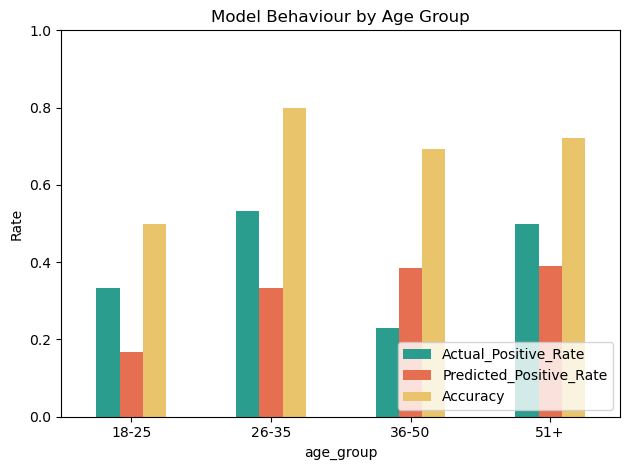

In [99]:
# Writing a helper that draws a grouped bar chart for one chosen group column
def plot_fairness(summary, group_column, title):
    # Picking the three measures we want to compare in the chart
    chart = summary.set_index(group_column)[["Actual_Positive_Rate", "Predicted_Positive_Rate", "Accuracy"]]
    # Drawing the grouped bars
    chart.plot(kind="bar")
    # Adding the chart title
    plt.title(title)
    # Adding a label under the bars
    plt.xlabel(group_column)
    # Adding a label on the side of the chart
    plt.ylabel("Rate")
    # Setting the side scale from 0 to 1
    plt.ylim(0, 1)
    # Keeping the bottom labels straight
    plt.xticks(rotation=0)
    # Placing the small key in the lower right corner
    plt.legend(loc="lower right")
    # Tidying the layout
    plt.tight_layout()
    # Showing the chart
    plt.show()

# Drawing the fairness chart for the age group column
plot_fairness(age_group_fairness, "age_group", "Model Behaviour by Age Group")

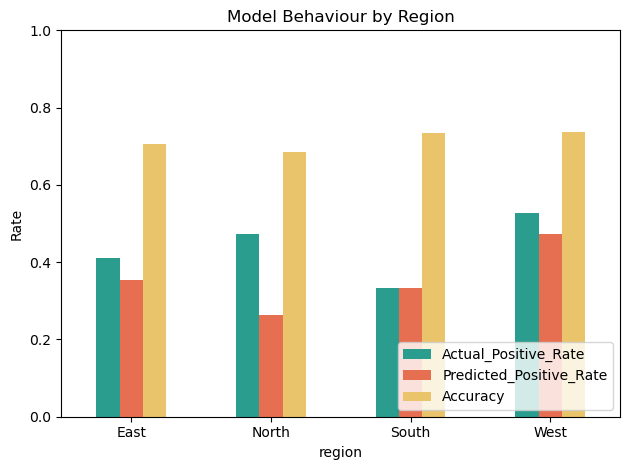

In [100]:
# Drawing the fairness chart for the region column
plot_fairness(region_fairness, "region", "Model Behaviour by Region")

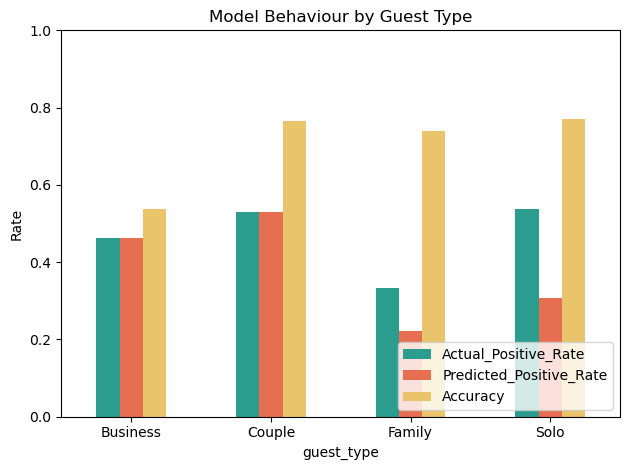

In [101]:
# Drawing the fairness chart for the guest type column
plot_fairness(guest_type_fairness, "guest_type", "Model Behaviour by Guest Type")

### Does the model behave fairly

I checked whether the model behaves the same for different groups of guests, even though I did not use the group columns as inputs, because a model can pick up uneven patterns through the other features. The simplest way to spot a problem is to compare two numbers for each group, the real cancel rate, which is how often that group actually cancels, and the predicted cancel rate, which is how often the model says that group will cancel. When the predicted rate sits well below the real rate, the model is missing cancellations in that group.

By age group, the accuracy ranged widely, from about 0.50 for the youngest guests aged 18 to 25 up to about 0.80 for guests aged 26 to 35. I am careful with the youngest group, though, because it had only 6 bookings in the test set, which is far too few to trust, so its low score may be chance rather than a real bias.

By region the accuracy was fairly close, between about 0.68 and 0.74, but the gap between the real and predicted cancel rates told a clearer story. In the North the real cancel rate was about 0.47 while the model predicted only about 0.26, a wide gap that means the model is missing a good share of cancellations in the North.

By guest type, two different problems show up. Solo guests are the clearest case of missed cancellations. Their real cancel rate is about 0.54, but the model predicted only about 0.31, a gap of more than twenty points, so the model is failing to flag many Solo cancellations. Business guests show a different problem. Their predicted cancel rate, about 0.46, is the same as their real cancel rate, so on the whole the model predicts the right number of Business cancellations, yet their accuracy is the lowest of any group at about 0.54, which means it gets the right total but the wrong individual bookings. Couple and Family guests are handled best, with accuracy around 0.74 to 0.77.

These gaps matter, because if the hotel acted only on the model, some groups would have their cancellations missed more often than others, most clearly Solo guests and guests in the North. Some of the gaps come from very small group sizes, so the exact numbers should be read with care, but the direction of the differences is real and worth watching. This is why the model needs a fairness review before it is trusted for real decisions, even though the group columns were never used as inputs.

## Task 15: Final Business Interpretation

This final section brings everything together and gives a clear business view of the model.

In [102]:
# Bringing in the confusion matrix tool one more time for the final summary
from sklearn.metrics import confusion_matrix

# Building the confusion matrix from the real answers and the guesses
cm = confusion_matrix(y_test, y_pred)

# Pulling out the four numbers again
tn, fp, fn, tp = cm.ravel()

# Gathering all the main results into one final table so everything is in one place
business_summary = pd.DataFrame({
    "Result": [
        "Training Accuracy", "Testing Accuracy", "Precision", "Recall", "F1-Score",
        "True Negative", "False Positive", "False Negative", "True Positive"
    ],
    "Value": [
        accuracy_score(y_train, model.predict(X_train)),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        tn, fp, fn, tp
    ]
})

# Showing the final summary table
business_summary

,Result,Value
0,Training Accuracy,0.789286
1,Testing Accuracy,0.714286
2,Precision,0.720000
3,Recall,0.580645
4,F1-Score,0.642857
5,True Negative,32.000000
6,False Positive,7.000000
7,False Negative,13.000000
8,True Positive,18.000000


### Final business interpretation

**What the model predicts.** The model predicts whether a hotel booking will be cancelled or kept. A prediction of 1 means the model expects a cancellation.

**Overall performance.** The model reaches a testing accuracy of about 0.71 and a cross-validation average close to 0.71 as well. This is moderate performance. The model is clearly better than guessing, but it is not strong enough to be fully trusted on its own.

**Most important metric.** Recall is the most important metric for this problem, because the hotel mainly wants to catch bookings that will cancel so it can resell the room in time. The recall here is about 0.58, which means the model still misses a fair share of real cancellations.

**Main error type.** The most common mistake is the false negative, where a booking that will cancel is labelled as kept. The model produced 13 false negatives against 7 false positives.

**Business impact of the errors.** False negatives are costly because a missed cancellation leaves a room empty at short notice with lost revenue. False positives are less costly but still waste effort, since the hotel may act on a booking that was never going to cancel.

**Overfitting or underfitting.** The model shows mild overfitting. Training accuracy is higher than testing accuracy, and the depth test shows that deeper trees memorise the training data while the testing score falls. A shallower tree would generalise a little better.

**Most important features.** The strongest signals were the lead time in days and the number of previous cancellations, followed by the deposit type and the room price. Bookings made far in advance and guests with a history of cancelling were the clearest warning signs.

**SHAP and LIME insight.** Both tools agreed that a long lead time and the deposit and cancellation history drive the predictions. For the single booking we studied, a long lead time and the absence of a non-refundable deposit pushed the prediction toward cancel, and the model was correct.

**Fairness and bias concern.** The model does not behave equally across groups. Accuracy and predicted cancel rates differ by age group, region, and guest type, and some groups, such as guests in the North and Solo guests, have their cancellations missed more often. Several groups are small, which adds uncertainty, but the gaps are real.

**Final recommendation.** This model is not ready for full real business use on its own. It is best treated as an early prototype. It gives useful insight into which bookings are risky and which features matter, but before it supports real decisions it needs improvement, for example more data, better features, tuning of the tree, fairness checks, and a comparison with other models such as Logistic Regression or Random Forest. Used carefully as a support tool rather than an automatic decision maker, it can still help the hotel start thinking about cancellation risk.